# **Using Logistic Regression , RandomForestClassifier And SVM**

##Importing the Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns #for visualization
import matplotlib.pyplot as plt

## Importing the dataset

In [4]:
dataset = pd.read_csv('water_potability.csv')
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:,-1].values


In [ ]:
print("First 5 Rows of the Dataset:\n", dataset.head())

First 5 Rows of the Dataset:
          ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [ ]:
print("Last 5 Rows of the Dataset:\n", dataset.tail())

Last 5 Rows of the Dataset:
             ph    Hardness        Solids  Chloramines     Sulfate  \
3271  4.668102  193.681735  47580.991603     7.166639  359.948574   
3272  7.808856  193.553212  17329.802160     8.061362         NaN   
3273  9.419510  175.762646  33155.578218     7.350233         NaN   
3274  5.126763  230.603758  11983.869376     6.303357         NaN   
3275  7.874671  195.102299  17404.177061     7.509306         NaN   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability  
3271    526.424171       13.894419        66.687695   4.435821           1  
3272    392.449580       19.903225              NaN   2.798243           1  
3273    432.044783       11.039070        69.845400   3.298875           1  
3274    402.883113       11.168946        77.488213   4.708658           1  
3275    327.459760       16.140368        78.698446   2.309149           1  


## Solving for missing data

In [ ]:
print("\nMissing Values in Each Column:\n", dataset.isnull().sum())



Missing Values in Each Column:
 ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [ ]:
dataset["ph"] = dataset["ph"].fillna(value=dataset["ph"].mean())
dataset["Sulfate"] = dataset["Sulfate"].fillna(value=dataset["Sulfate"].mean())
dataset["Trihalomethanes"] = dataset["Trihalomethanes"].fillna(value=dataset["Trihalomethanes"].mean())

In [ ]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
print("\nMissing Values in Each Column:\n", dataset.isnull().sum())


Missing Values in Each Column:
 ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


## Splitting the dataset into the Training set and Test set

In [ ]:
X = dataset.drop("Potability",axis=1)
y= dataset["Potability"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=13)

## Feature Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

##DATA VISUALISING

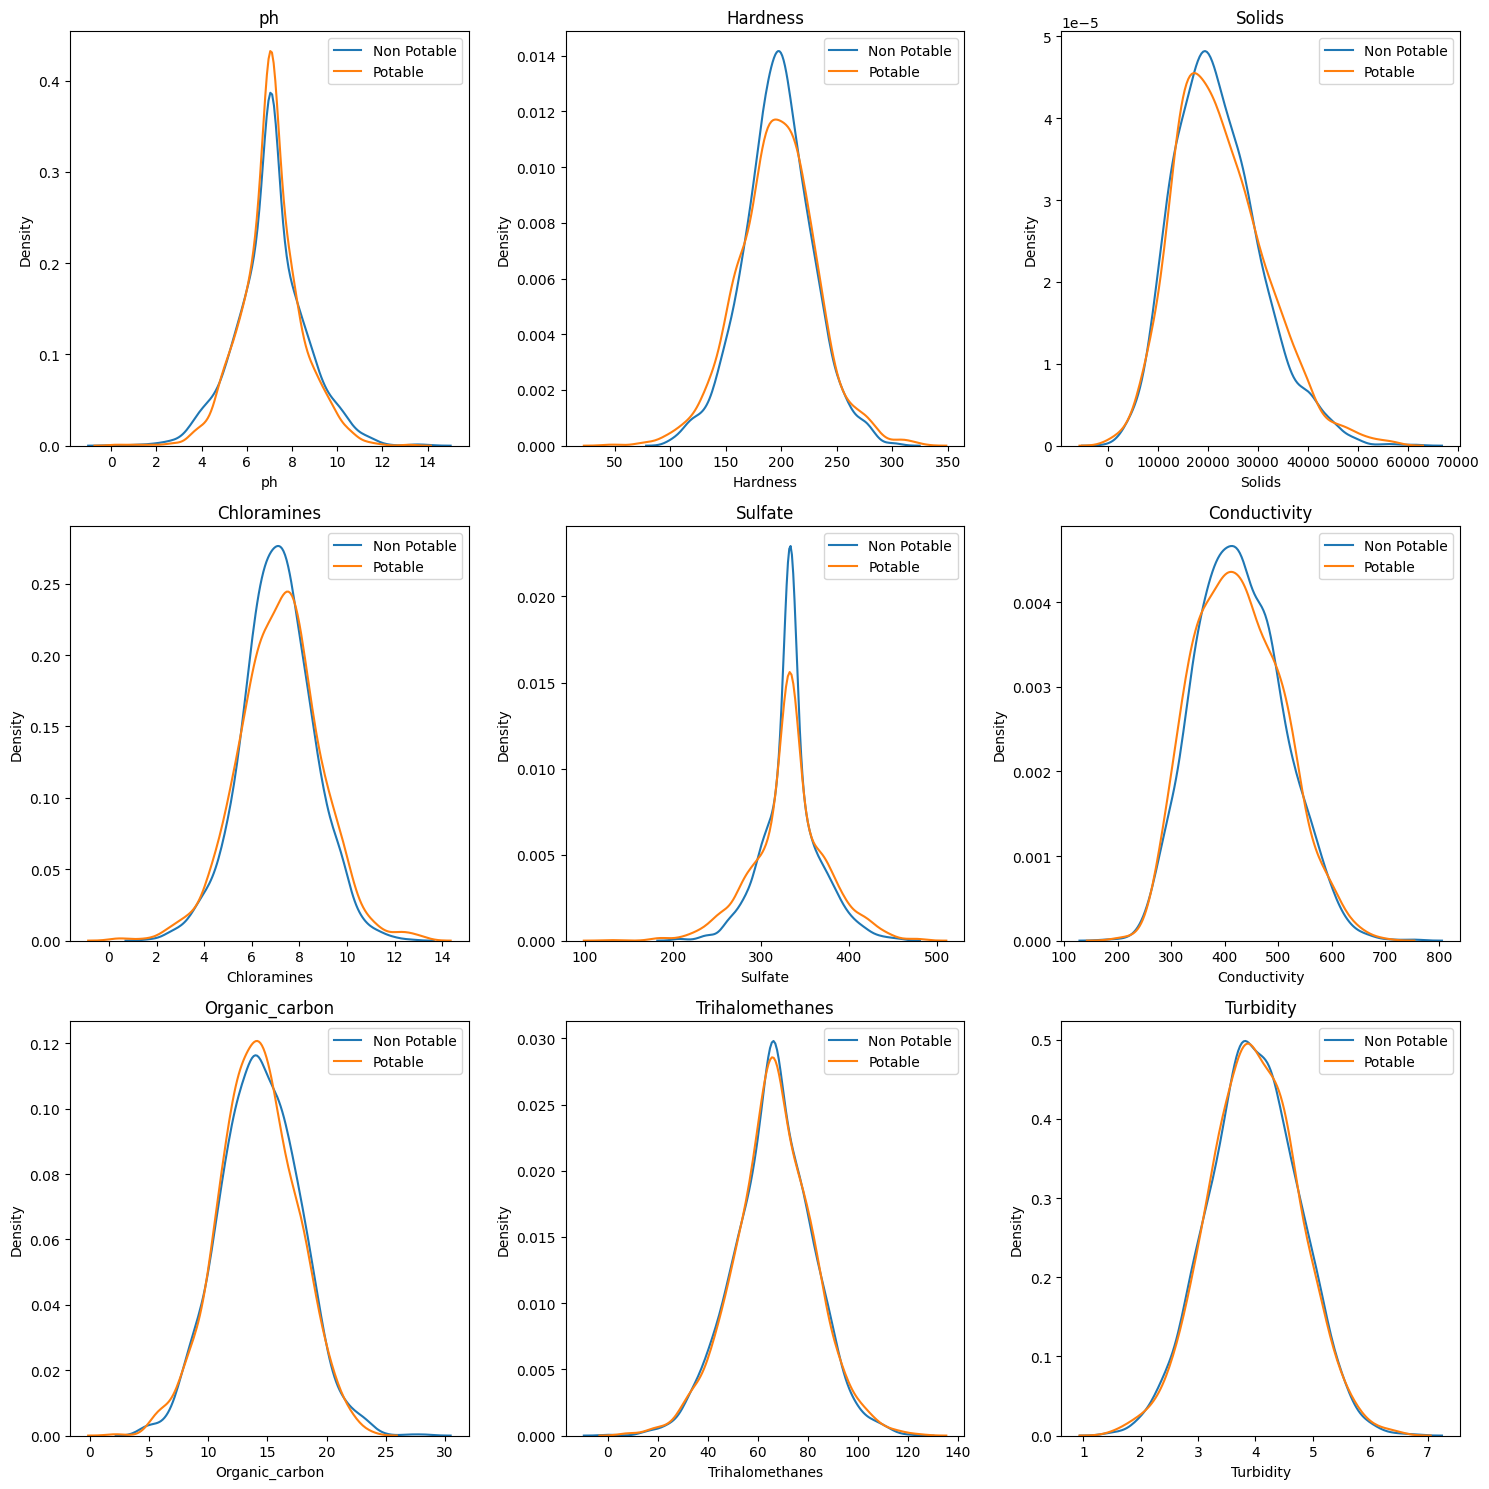

In [ ]:
potability_zero = dataset.query("Potability == 0")
potable = dataset.query("Potability == 1")

plt.figure(figsize = (15,15))
for ax, col in enumerate(dataset.columns[:9]):
    plt.subplot(3,3,ax+1)
    plt.title(col)
    sns.kdeplot(x=potability_zero[col],label = "Non Potable")
    sns.kdeplot(x = potable[col],label = "Potable")
    plt.legend()
plt.tight_layout()

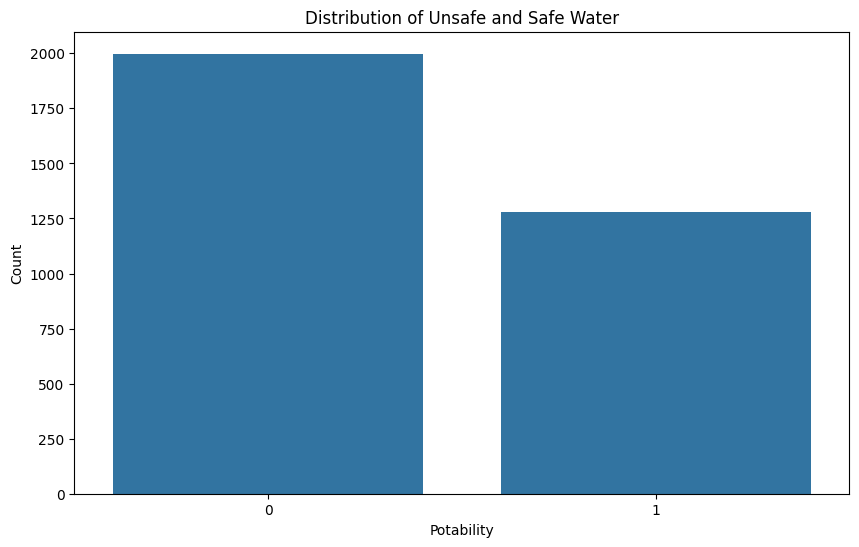

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x='Potability')
plt.title("Distribution of Unsafe and Safe Water")
plt.xlabel("Potability")
plt.ylabel("Count")
plt.show()


## Training the Logistic Regression model on the Training set

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)
# Fit the model
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

## Training the SVM model on the Training set

In [ ]:
from sklearn.svm import SVC
svm = SVC(kernel="rbf")
svm.fit(X_train, y_train)

SVC()

# Training the random forestclassifier model on the Training set

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
# Fit the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Predicting a new result

In [ ]:
new_data = pd.DataFrame({
    'ph': [7.5],
    'Hardness': [150],
    'Solids': [200],
    'Chloramines': [0.5],
    'Sulfate': [100],
    'Conductivity': [500],
    'Organic_carbon': [10],
    'Trihalomethanes': [0.1],
    'Turbidity': [0.5]
})

new_prediction = lr_model.predict(new_data)

if new_prediction == 0:
    print("The water is non-potable.")
else:
    print("The water is potable.")



The water is non-potable.


## Predicting the Test set results

*  Linear Regression
*  SVM
*  Random Forest Classifier


In [ ]:
from sklearn.metrics import accuracy_score
# Predict test set results using Logistic Regression
lr_test_pred = lr_model.predict(X_test)
lr_test_accuracy = accuracy_score(y_test, lr_test_pred)
print("Logistic Regression Test Accuracy:", lr_test_accuracy)

Logistic Regression Test Accuracy: 0.6189024390243902


In [ ]:
from sklearn.metrics import accuracy_score
# Predict test set results using SVM
svm_test_pred = svm.predict(X_test)
svm_test_accuracy = accuracy_score(y_test, svm_test_pred)
print("SVM Test Accuracy:", svm_test_accuracy)

SVM Test Accuracy: 0.6204268292682927


In [ ]:
from sklearn.metrics import accuracy_score
# Predict test set results using random forestclassifier
rf_test_pred = rf_model.predict(X_test)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)
print("Random forestclassifier Test Accuracy:", rf_test_accuracy)

Random forestclassifier Test Accuracy: 0.6432926829268293


## Making the Confusion Matrix

Logistic Regression Confusion Matrix:
[[406   1]
 [249   0]]

SVM Confusion Matrix:
[[407   0]
 [249   0]]

Random forest classifier Confusion Matrix:
[[345  62]
 [172  77]]

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.76       407
           1       0.00      0.00      0.00       249

    accuracy                           0.62       656
   macro avg       0.31      0.50      0.38       656
weighted avg       0.38      0.62      0.47       656


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.77       407
           1       0.00      0.00      0.00       249

    accuracy                           0.62       656
   macro avg       0.31      0.50      0.38       656
weighted avg       0.38      0.62      0.48       656


Random forest classifier Classification Report:
              precision    recall  f1-score   suppo

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


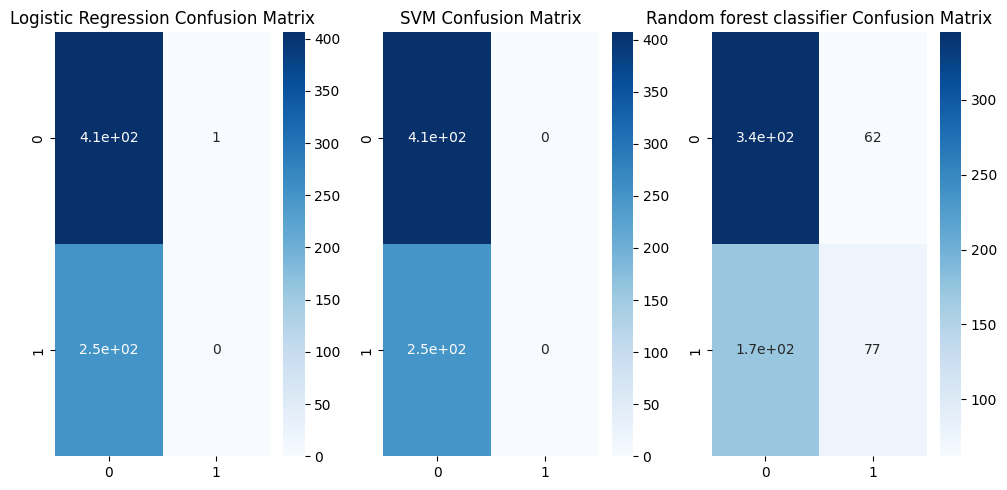

In [ ]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, classification_report

# Create confusion matrices
lr_confusion_matrix = confusion_matrix(y_test, lr_test_pred)
svm_confusion_matrix = confusion_matrix(y_test, svm_test_pred)
rf_confusion_matrix = confusion_matrix(y_test, rf_test_pred)

# Print confusion matrices
print("Logistic Regression Confusion Matrix:")
print(lr_confusion_matrix)

print("\nSVM Confusion Matrix:")
print(svm_confusion_matrix)

print("\nRandom forest classifier Confusion Matrix:")
print(rf_confusion_matrix)

# Create classification reports
lr_classification_report = classification_report(y_test, lr_test_pred)
svm_classification_report = classification_report(y_test, svm_test_pred)
rf_classification_report = classification_report(y_test, rf_test_pred)

# Print classification reports
print("\nLogistic Regression Classification Report:")
print(lr_classification_report)

print("\nSVM Classification Report:")
print(svm_classification_report)

print("\nRandom forest classifier Classification Report:")
print(rf_classification_report)

# Plot confusion matrices using seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
sns.heatmap(lr_confusion_matrix, annot=True, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")

plt.subplot(1,3,2)
sns.heatmap(svm_confusion_matrix, annot=True, cmap="Blues")
plt.title("SVM Confusion Matrix")

plt.subplot(1,3,3)
sns.heatmap(rf_confusion_matrix, annot=True, cmap="Blues")
plt.title("Random forest classifier Confusion Matrix")

plt.tight_layout()
plt.show()

##Hyperparameter search

In [ ]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30]
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Best model and evaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.67      0.85      0.75       407
           1       0.57      0.31      0.40       249

    accuracy                           0.65       656
   macro avg       0.62      0.58      0.58       656
weighted avg       0.63      0.65      0.62       656



## Visualising the Training set results

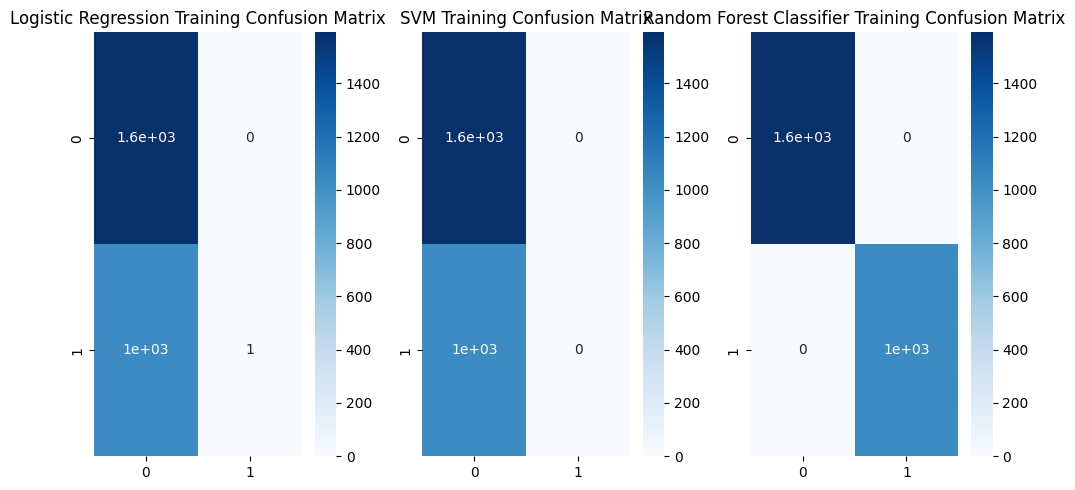

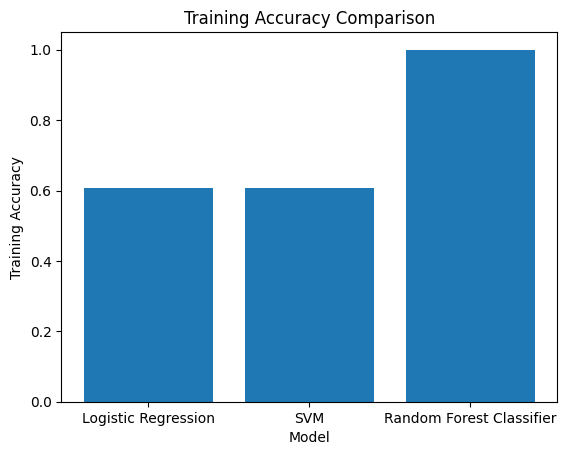

Logistic Regression Training Classification Report:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76      1591
           1       1.00      0.00      0.00      1029

    accuracy                           0.61      2620
   macro avg       0.80      0.50      0.38      2620
weighted avg       0.76      0.61      0.46      2620


SVM Training Classification Report:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76      1591
           1       0.00      0.00      0.00      1029

    accuracy                           0.61      2620
   macro avg       0.30      0.50      0.38      2620
weighted avg       0.37      0.61      0.46      2620


Random Forest Classifier Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1591
           1       1.00      1.00      1.00      1029

    accuracy                       

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict training set results
lr_train_pred = lr_model.predict(X_train)
svm_train_pred = svm.predict(X_train)
rf_train_pred = rf_model.predict(X_train)

# Create confusion matrices
lr_train_confusion_matrix = confusion_matrix(y_train, lr_train_pred)
svm_train_confusion_matrix = confusion_matrix(y_train, svm_train_pred)
rf_train_confusion_matrix = confusion_matrix(y_train, rf_train_pred)

# Plot confusion matrices using seaborn
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
sns.heatmap(lr_train_confusion_matrix, annot=True, cmap="Blues")
plt.title("Logistic Regression Training Confusion Matrix")

plt.subplot(1,3,2)
sns.heatmap(svm_train_confusion_matrix, annot=True, cmap="Blues")
plt.title("SVM Training Confusion Matrix")

plt.subplot(1,3,3)
sns.heatmap(rf_train_confusion_matrix, annot=True, cmap="Blues")
plt.title("Random Forest Classifier Training Confusion Matrix")

plt.tight_layout()
plt.show()

# Plot training accuracy
plt.bar(["Logistic Regression", "SVM", "Random Forest Classifier"],
        [accuracy_score(y_train, lr_train_pred), accuracy_score(y_train, svm_train_pred),accuracy_score(y_train, rf_train_pred)])
plt.xlabel("Model")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")
plt.show()

# Print classification reports
print("Logistic Regression Training Classification Report:")
print(classification_report(y_train, lr_train_pred))

print("\nSVM Training Classification Report:")
print(classification_report(y_train, svm_train_pred))

print("\nRandom Forest Classifier Training Classification Report:")
print(classification_report(y_train, rf_train_pred))

## Visualising the Test set results

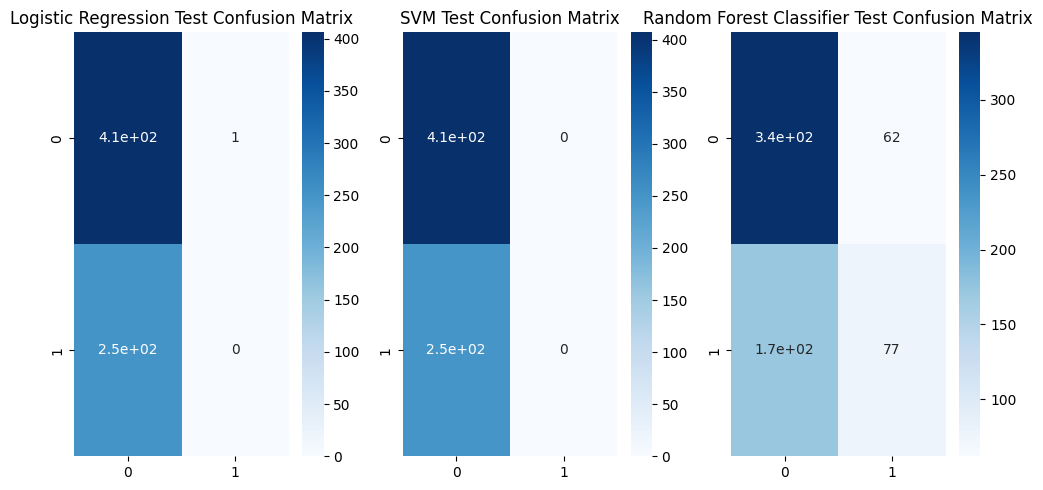

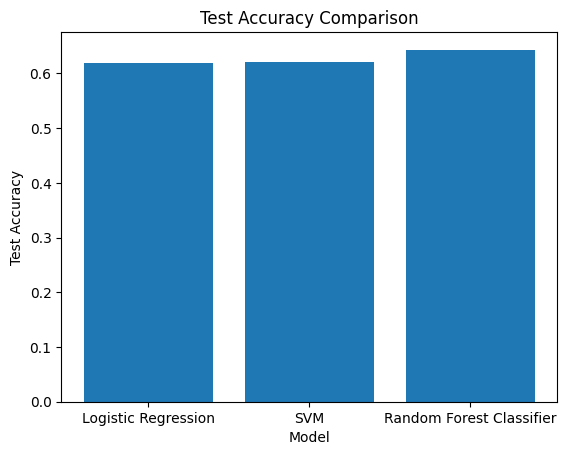

Logistic Regression Test Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.76       407
           1       0.00      0.00      0.00       249

    accuracy                           0.62       656
   macro avg       0.31      0.50      0.38       656
weighted avg       0.38      0.62      0.47       656


SVM Test Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.77       407
           1       0.00      0.00      0.00       249

    accuracy                           0.62       656
   macro avg       0.31      0.50      0.38       656
weighted avg       0.38      0.62      0.48       656


Random Forest Classifier Test Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.85      0.75       407
           1       0.55      0.31      0.40       249

    accuracy                           0.64    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


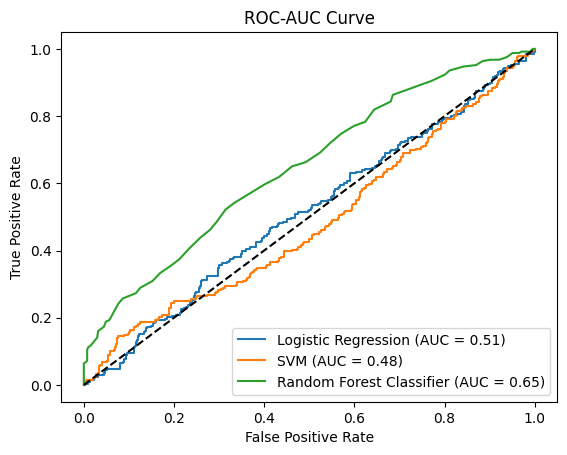

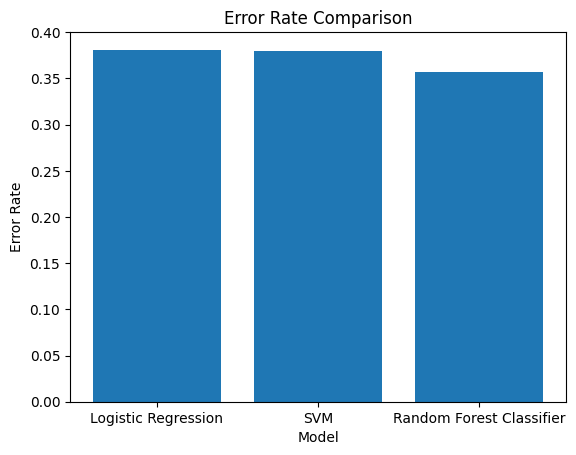

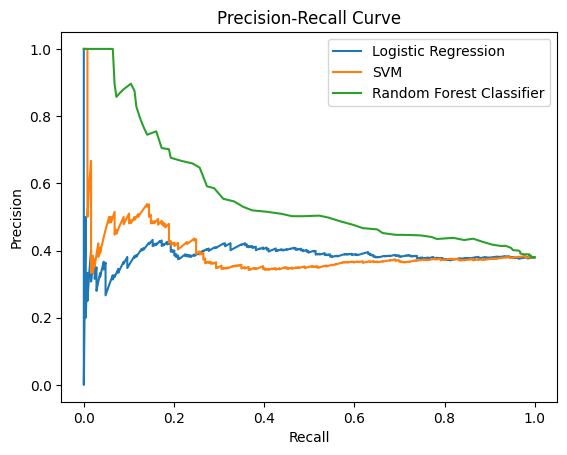

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Predict test set results
lr_test_pred = lr_model.predict(X_test)
svm_test_pred = svm.predict(X_test)
rf_test_pred = rf_model.predict(X_test)

# Create confusion matrices
lr_test_confusion_matrix = confusion_matrix(y_test, lr_test_pred)
svm_test_confusion_matrix = confusion_matrix(y_test, svm_test_pred)
rf_test_confusion_matrix = confusion_matrix(y_test, rf_test_pred)

# Plot confusion matrices using seaborn
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
sns.heatmap(lr_test_confusion_matrix, annot=True, cmap="Blues")
plt.title("Logistic Regression Test Confusion Matrix")

plt.subplot(1,3,2)
sns.heatmap(svm_test_confusion_matrix, annot=True, cmap="Blues")
plt.title("SVM Test Confusion Matrix")

plt.subplot(1,3,3)
sns.heatmap(rf_test_confusion_matrix, annot=True, cmap="Blues")
plt.title("Random Forest Classifier Test Confusion Matrix")

plt.tight_layout()
plt.show()

# Plot test accuracy
plt.bar(["Logistic Regression", "SVM","Random Forest Classifier"],
        [accuracy_score(y_test, lr_test_pred), accuracy_score(y_test, svm_test_pred),accuracy_score(y_test, rf_test_pred)])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.show()

# Print classification reports
print("Logistic Regression Test Classification Report:")
print(classification_report(y_test, lr_test_pred))

print("\nSVM Test Classification Report:")
print(classification_report(y_test, svm_test_pred))

print("\nRandom Forest Classifier Test Classification Report:")
print(classification_report(y_test, rf_test_pred))

# ROC-AUC Curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:,1])
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm.decision_function(X_test))
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression (AUC = %0.2f)" % roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]))
plt.plot(svm_fpr, svm_tpr, label="SVM (AUC = %0.2f)" % roc_auc_score(y_test, svm.decision_function(X_test)))
plt.plot(rf_fpr, rf_tpr, label="Random Forest Classifier (AUC = %0.2f)" % roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

# Plot error rates
error_rates = [1 - accuracy_score(y_test, lr_test_pred), 1 - accuracy_score(y_test, svm_test_pred), 1 - accuracy_score(y_test, rf_test_pred)]
plt.bar(["Logistic Regression", "SVM","Random Forest Classifier"], error_rates)
plt.xlabel("Model")
plt.ylabel("Error Rate")
plt.title("Error Rate Comparison")
plt.show()

# Plot precision-recall curve
from sklearn.metrics import precision_recall_curve
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_model.predict_proba(X_test)[:,1])
svm_precision, svm_recall, _ = precision_recall_curve(y_test, svm.decision_function(X_test))
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_model.predict_proba(X_test)[:,1])

plt.plot(lr_recall, lr_precision, label="Logistic Regression")
plt.plot(svm_recall, svm_precision, label="SVM")
plt.plot(rf_recall, rf_precision, label="Random Forest Classifier")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()